<a href="https://colab.research.google.com/github/takuonakashima/ai-security-workshop/blob/main/vaccine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 464kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.66MB/s]


💉 AIにワクチンを接種しています（敵対的学習を開始）...
  > 進捗: 50 バッチ完了
  > 進捗: 100 バッチ完了
  > 進捗: 150 バッチ完了
  > 進捗: 200 バッチ完了
✅ ワクチン接種完了！ノイズに強い「堅牢なAI」が完成しました。

🛡️ ワクチン接種済みAIへのサイバー攻撃テストを開始します...
----------------------------------------
本当の正解: 『 7 』
✅ 防御成功！ ノイズに騙されず『 7 』と見破りました！
   (確信度: 97.47%)
----------------------------------------


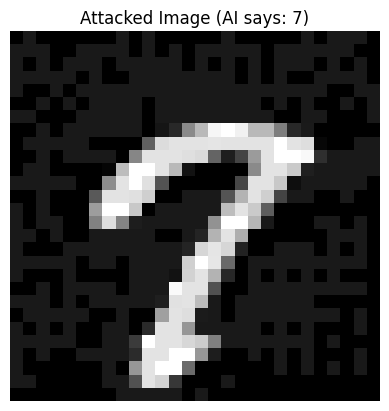

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ==========================================
# 1. 基本設定とデータの準備
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# デモを早く終わらせるため、バッチサイズを大きめに設定
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# ==========================================
# 2. モデルと攻撃手法の定義
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

secure_model = SimpleCNN().to(device)
optimizer = optim.Adam(secure_model.parameters(), lr=0.001)

# ==========================================
# 3. ワクチン生成と接種（敵対的学習）
# ==========================================
print("💉 AIにワクチンを接種しています（敵対的学習を開始）...")
secure_model.train()

vaccine_epsilon = 0.15 # 訓練時に使うノイズの強さ（強めの抗体を作らせる）

# 処理時間を短くするため、200バッチだけ学習させます
for i, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)

    # --- ステップA：AIの弱点を探る（疑似攻撃） ---
    data.requires_grad = True
    output = secure_model(data)
    loss = F.cross_entropy(output, target)
    optimizer.zero_grad()
    loss.backward()
    data_grad = data.grad.data

    # --- ステップB：だまし討ち画像（ウイルス）を生成 ---
    perturbed_data = fgsm_attack(data, vaccine_epsilon, data_grad)

    # --- ステップC：ワクチン接種（ノイズ画像で学習） ---
    # ノイズが入った画像を見せても、正しい答えを出せるようにパラメータを更新する
    optimizer.zero_grad()
    # detach() で疑似攻撃時の計算グラフを切り離す
    output_adv = secure_model(perturbed_data.detach())
    loss_adv = F.cross_entropy(output_adv, target)
    loss_adv.backward()
    optimizer.step()

    if (i + 1) % 50 == 0:
        print(f"  > 進捗: {i + 1} バッチ完了")

    if i == 200:
        break

print("✅ ワクチン接種完了！ノイズに強い「堅牢なAI」が完成しました。\n")

# ==========================================
# 4. サイバー攻撃テスト
# ==========================================
secure_model.eval()
print("🛡️ ワクチン接種済みAIへのサイバー攻撃テストを開始します...")

dataiter = iter(train_loader)
images, labels = next(dataiter)

image = images[0].unsqueeze(0).to(device)
label = labels[0].unsqueeze(0).to(device)

epsilon = 0.1 # テスト時の攻撃の強さ
image.requires_grad = True

output = secure_model(image)
loss = F.cross_entropy(output, label)
secure_model.zero_grad()
loss.backward()
data_grad = image.grad.data

perturbed_data = fgsm_attack(image, epsilon, data_grad)

output_adv = secure_model(perturbed_data)
max_prob_adv, predicted_adv = torch.max(F.softmax(output_adv, dim=1), 1)

print("-" * 40)
print(f"本当の正解: 『 {label.item()} 』")

if predicted_adv.item() == label.item():
    print(f"✅ 防御成功！ ノイズに騙されず『 {predicted_adv.item()} 』と見破りました！")
    print(f"   (確信度: {max_prob_adv.item()*100:.2f}%)")
else:
    print(f"❌ 防御失敗... 『 {predicted_adv.item()} 』に誤認識してしまいました。")

print("-" * 40)

plt.imshow(perturbed_data.cpu().detach().squeeze().numpy(), cmap='gray')
plt.title(f"Attacked Image (AI says: {predicted_adv.item()})")
plt.axis('off')
plt.show()